# Fine-Tuning Sentiment: GPT + IndoBERT + RoBERTa Ensemble

**Strategi**:
1. Ambil prediksi dari 3 model (GPT, IndoBERT, RoBERTa API) via checkpoint + API call
2. Majority vote 3 model sebagai **silver labels** untuk training
3. Fine-tune `cardiffnlp/twitter-xlm-roberta-base-sentiment-multilingual` (sudah punya sentiment head)
4. Evaluasi pada **random test set** (representatif) + **error test set** (kasus sulit)

| Model | Source |
|---|---|
| GPT 5.4 mini | `gpt_label` di checkpoint CSV |
| IndoBERT | `indobert_label` di checkpoint CSV |
| RoBERTa API | `http://103.67.43.247:9443/sentiment/infer-sentiment-roberta` |

In [ ]:
! pip install -q transformers torch scikit-learn pandas numpy matplotlib seaborn accelerate

In [1]:
import os, warnings, time, requests, json, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import torch, torch.nn as nn
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report

warnings.filterwarnings('ignore')
print('Libraries loaded OK')

Libraries loaded OK


## 1. Konfigurasi

In [2]:
CONFIG = {
    "model_name": "cardiffnlp/twitter-xlm-roberta-base-sentiment-multilingual",
    "roberta_api": "http://103.67.43.247:9443/sentiment/infer-sentiment-roberta",
    "phase1_epochs": 3,
    "phase1_lr": 5e-4,
    "phase1_batch_size": 32,
    "phase2_epochs": 5,
    "phase2_lr": 2e-5,
    "phase2_batch_size": 16,
    "max_length": 128,
    "val_split": 0.1,
    "warmup_steps": 0.1,
    "weight_decay": 0.01,
    "early_stopping_patience": 2,
    "seed": 42,
    "random_test_per_topic": 70,   # jumlah random sample per topik untuk test set baru
    "output_dir": "finetuned_sentiment",
}

LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL = {0: "negative", 1: "neutral", 2: "positive"}
LABEL_NORM = {
    "negative": "negative", "neg": "negative", "negatif": "negative", "0": "negative",
    "neutral": "neutral", "neu": "neutral", "netral": "neutral", "1": "neutral",
    "positive": "positive", "pos": "positive", "positif": "positive", "2": "positive",
}
TOPICS = ["boikot", "vaksin", "indonesia_gelap"]

LABELED_FILES = {
    "boikot": {"path": "hasil_boikot/boikot_error_samples_labeled.csv", "pred_col": "indobert_label"},
    "vaksin": {"path": "hasil_vaksin/vaksin_error_samples_labeled.csv", "pred_col": "gpt_label"},
    "indonesia_gelap": {"path": "hasil_indonesia_gelap/indonesia_gelap_error_samples_labeled.csv", "pred_col": "indobert_label"},
}
CHECKPOINT_FILES = {
    "boikot": "code_boikot/boikot_checkpoint_gpt54_sentiment.csv",
    "vaksin": "code_vaksin/vaksin_checkpoint_gpt54_sentiment.csv",
    "indonesia_gelap": "code_indonesia_gelap/indonesia_gelap_checkpoint_gpt54_sentiment.csv",
}
FULL_CSV_FILES = {
    "boikot": "total_data_cleaned_mcd.csv",
    "vaksin": "total_data_cleaned_vaksin.csv",
    "indonesia_gelap": "total_data_cleaned_indonesia_gelap.csv",
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Model: {CONFIG['model_name']}")

Device: cuda
GPU: NVIDIA GeForce RTX 5070
Model: cardiffnlp/twitter-xlm-roberta-base-sentiment-multilingual


## 2. Buat Random Test Set (Representatif)

**Kenapa?** File `error_samples_labeled.csv` hanya berisi kasus tersulit (yang model salah prediksi). Ini **bukan** representasi data sebenarnya.

Test set yang benar = **random sample** dari seluruh data, lalu di-label manual.

Cell ini akan:
1. Random sample 70 teks per topik dari `total_data_cleaned_*.csv`
2. Export ke CSV untuk di-label manual
3. Setelah di-label, simpan ke `hasil_*/..._random_labeled.csv`

In [ ]:
# ============================================================
# 2A. Generate Random Sample untuk Manual Labeling
# ============================================================
random.seed(CONFIG["seed"])
RANDOM_TEST_FILE = "random_test_samples_TO_LABEL.csv"

all_samples = []
for topic in TOPICS:
    df = pd.read_csv(FULL_CSV_FILES[topic],
                     usecols=["cleaned_text", "final_sentiment"],
                     dtype=str, low_memory=False).fillna("")
    df["text"] = df["cleaned_text"].str.strip()
    df = df[df["text"].str.len() > 10].copy()

    n_per_topic = CONFIG["random_test_per_topic"]
    sampled = df.sample(n=min(len(df), n_per_topic), random_state=CONFIG["seed"])
    sampled = sampled.copy()
    sampled["topic"] = topic
    all_samples.append(sampled[["text", "final_sentiment", "topic"]])
    print(f"{topic}: sampled {len(sampled)} texts")

df_random = pd.concat(all_samples, ignore_index=True)
df_random["manual_label"] = ""

df_random.to_csv(RANDOM_TEST_FILE, index=False, encoding="utf-8-sig")
print(f"Exported {len(df_random)} samples to: {RANDOM_TEST_FILE}")
print("*** LANGKAH SELANJUTNYA ***")
print("1. Buka file tersebut di Excel/Google Sheets")
print("2. Isi kolom manual_label dengan: negative / neutral / positive")
print("3. Simpan sebagai random_test_samples_LABELED.csv, lalu lanjut ke cell berikutnya")
df_random.head(10)

In [3]:
# ============================================================
# 2B. Load Random Test Set (setelah di-label manual)
# ============================================================
# Cek apakah sudah ada file yang sudah di-label
RANDOM_LABELED_FILE = "random_test_samples_TO_LABEL.csv"

import os
if os.path.exists(RANDOM_LABELED_FILE):
    df_random_test = pd.read_csv(RANDOM_LABELED_FILE, dtype=str).fillna("")
    df_random_test["label"] = df_random_test["manual_label"].map(
        lambda x: LABEL_NORM.get(str(x).strip().lower(), "")
    )
    df_random_test = df_random_test[df_random_test["label"].isin(LABEL2ID)].copy()
    print(f"Random test set loaded: {len(df_random_test)} labeled samples")
    print(df_random_test["label"].value_counts())
    HAS_RANDOM_TEST = True
else:
    print(f"File '{RANDOM_LABELED_FILE}' belum ada.")
    print(f"Label dulu file '{RANDOM_TEST_FILE}', simpan sebagai '{RANDOM_LABELED_FILE}', lalu re-run cell ini.")
    print("\nSementara akan pakai error_samples sebagai test set.")
    HAS_RANDOM_TEST = False

Random test set loaded: 210 labeled samples
label
negative    99
neutral     92
positive    19
Name: count, dtype: int64


## 3. Load Data

In [4]:
# ============================================================
# 3A. Load Error Test Set (Gold Standard - kasus sulit)
# ============================================================
def normalize_label(x):
    return LABEL_NORM.get(str(x).strip().lower(), "")

dfs_error_test = []
for topic, info in LABELED_FILES.items():
    df = pd.read_csv(info["path"], dtype=str).fillna("")
    df["text"] = df["cleaned_text"].str.strip()
    df["label"] = df["manual_label"].map(normalize_label)
    df = df[df["label"].isin(LABEL2ID)][["text", "label"]].assign(topic=topic)
    dfs_error_test.append(df)

df_error_test = pd.concat(dfs_error_test, ignore_index=True)
print(f"Error test set: {len(df_error_test)} samples (kasus sulit)")

# Pilih test set utama
if HAS_RANDOM_TEST:
    df_test = df_random_test
    print(f">>> Menggunakan RANDOM test set ({len(df_test)} samples) untuk evaluasi utama")
else:
    df_test = df_error_test
    print(f">>> Menggunakan ERROR test set ({len(df_test)} samples) — harap buat random test set untuk evaluasi fair")

Error test set: 180 samples (kasus sulit)
>>> Menggunakan RANDOM test set (210 samples) untuk evaluasi utama


In [5]:
# ============================================================
# 3B. Load Checkpoint Data (sudah punya gpt_label + indobert_label)
# ============================================================
dfs_cp = []
for topic in TOPICS:
    df = pd.read_csv(CHECKPOINT_FILES[topic], dtype=str, low_memory=False).fillna("")
    df["text"] = df["cleaned_text"].str.strip()
    df = df[df["text"].str.len() > 0].copy()
    df["gpt_label"] = df["gpt_label"].map(normalize_label)
    df["indobert_label"] = df["indobert_label"].map(normalize_label)
    df["topic"] = topic
    dfs_cp.append(df)
    print(f"Checkpoint {topic:20s}: {len(df):5d} rows")

df_checkpoint = pd.concat(dfs_cp, ignore_index=True)
print(f"Total checkpoint: {len(df_checkpoint)}")

Checkpoint boikot              : 10000 rows
Checkpoint vaksin              : 10000 rows
Checkpoint indonesia_gelap     : 10000 rows
Total checkpoint: 30000


In [6]:
# ============================================================
# 3C. Panggil RoBERTa API untuk semua checkpoint teks
# ============================================================
def call_roberta_api(texts, batch_size=200):
    results = []
    api_url = CONFIG["roberta_api"]
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        payload = {"list": [{"text": t} for t in batch]}
        try:
            resp = requests.post(api_url, json=payload, timeout=120)
            resp.raise_for_status()
            data = resp.json()
            for item in data.get("list", []):
                label = normalize_label(item.get("label", ""))
                prob = float(item.get("probability", 0))
                results.append((label, prob))
        except Exception as e:
            print(f"  API error at batch {i}: {e}")
            results.extend([("", 0.0)] * len(batch))
        if (i // batch_size) % 10 == 0:
            print(f"  Progress: {min(i+batch_size, len(texts))}/{len(texts)}")
    return results

print("Memanggil RoBERTa API untuk 30K teks (estimasi 2-5 menit)...")
t0 = time.time()
roberta_results = call_roberta_api(df_checkpoint["text"].tolist(), batch_size=200)
df_checkpoint["roberta_label"] = [r[0] for r in roberta_results]
df_checkpoint["roberta_prob"] = [r[1] for r in roberta_results]
print(f"Selesai dalam {time.time()-t0:.1f}s | Valid: {(df_checkpoint['roberta_label'] != '').sum()}/{len(df_checkpoint)}")

Memanggil RoBERTa API untuk 30K teks (estimasi 2-5 menit)...
  Progress: 200/30000
  Progress: 2200/30000
  Progress: 4200/30000
  Progress: 6200/30000
  Progress: 8200/30000
  Progress: 10200/30000
  Progress: 12200/30000
  Progress: 14200/30000
  Progress: 16200/30000
  Progress: 18200/30000
  Progress: 20200/30000
  Progress: 22200/30000
  Progress: 24200/30000
  Progress: 26200/30000
  Progress: 28200/30000
Selesai dalam 90.9s | Valid: 30000/30000


## 4. Majority Vote dari 3 Model

In [7]:
# ============================================================
# Majority Vote: GPT + IndoBERT + RoBERTa -> Silver Label
# ============================================================
def majority_vote_3(row):
    votes = [row.get(c, "") for c in ["gpt_label", "indobert_label", "roberta_label"]]
    votes = [v for v in votes if v in LABEL2ID]
    if not votes:
        return ""
    counts = Counter(votes)
    if counts.most_common(1)[0][1] >= 2:
        return counts.most_common(1)[0][0]
    # Tie: pilih RoBERTa (paling terkalibrasi)
    return row.get("roberta_label", votes[0])

df_checkpoint["silver_label"] = df_checkpoint.apply(majority_vote_3, axis=1)
df_checkpoint = df_checkpoint[df_checkpoint["silver_label"].isin(LABEL2ID)].copy()

# Agreement stats
def get_agreement(row):
    votes = [row.get(c, "") for c in ["gpt_label", "indobert_label", "roberta_label"]]
    votes = [v for v in votes if v in LABEL2ID]
    counts = Counter(votes)
    top = counts.most_common(1)[0][1] if counts else 0
    if top == 3: return "3_agree"
    elif top == 2: return "2_agree"
    return "no_agree"

df_checkpoint["agreement"] = df_checkpoint.apply(get_agreement, axis=1)
print("=== Agreement Statistics ===")
print(df_checkpoint["agreement"].value_counts())
print()
print("=== Silver Label Distribution ===")
print(df_checkpoint["silver_label"].value_counts())
print()
for m in ["gpt_label", "indobert_label", "roberta_label"]:
    match = (df_checkpoint[m] == df_checkpoint["silver_label"]).mean()
    print(f"{m:20s} agrees with silver: {match:.1%}")

=== Agreement Statistics ===
agreement
2_agree     15557
3_agree     13646
no_agree      797
Name: count, dtype: int64

=== Silver Label Distribution ===
silver_label
negative    16966
neutral     11311
positive     1723
Name: count, dtype: int64

gpt_label            agrees with silver: 75.0%
indobert_label       agrees with silver: 84.4%
roberta_label        agrees with silver: 83.4%


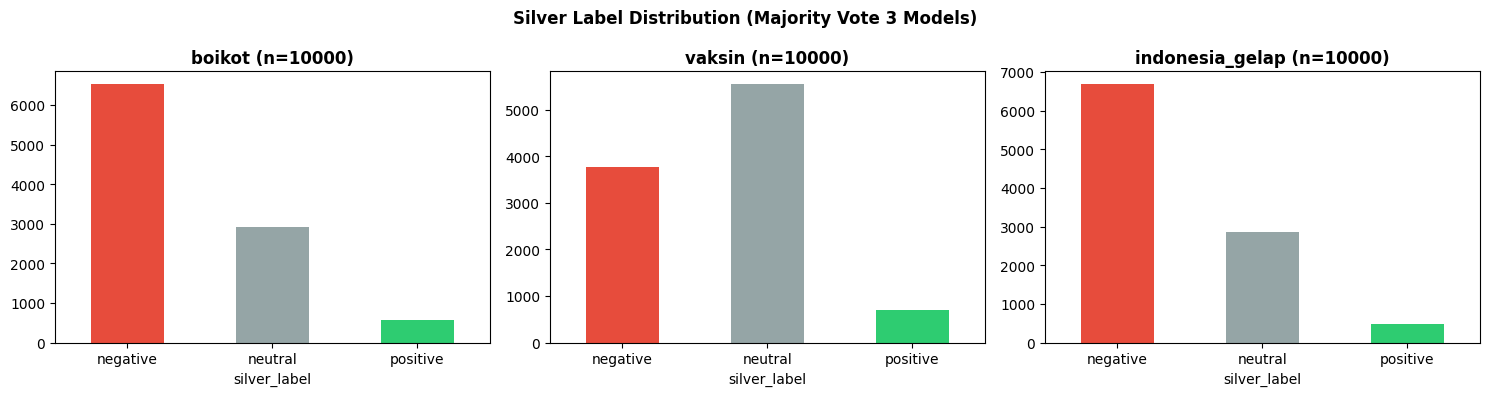

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {"negative": "#e74c3c", "neutral": "#95a5a6", "positive": "#2ecc71"}
for i, topic in enumerate(TOPICS):
    subset = df_checkpoint[df_checkpoint["topic"] == topic]
    counts = subset["silver_label"].value_counts().reindex(["negative","neutral","positive"], fill_value=0)
    counts.plot.bar(ax=axes[i], color=[colors[c] for c in counts.index])
    axes[i].set_title(f"{topic} (n={len(subset)})", fontweight="bold")
    axes[i].tick_params(axis="x", rotation=0)
plt.suptitle("Silver Label Distribution (Majority Vote 3 Models)", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Prepare Training Data

In [9]:
# ============================================================
# Train / Val Split + Class Weights
# ============================================================
df_silver = df_checkpoint[["text", "silver_label", "topic"]].rename(columns={"silver_label": "label"})
X = df_silver["text"].tolist()
y = df_silver["label"].map(LABEL2ID).tolist()

train_texts, val_texts, train_labels, val_labels = train_test_split(
    X, y, test_size=CONFIG["val_split"], stratify=y, random_state=CONFIG["seed"]
)
test_texts_list = df_test["text"].tolist()
test_labels_list = df_test["label"].map(LABEL2ID).tolist()

class_weights_np = compute_class_weight("balanced", classes=np.array([0,1,2]), y=np.array(train_labels))
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float32)
print(f"Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts_list)}")

Train: 27000, Val: 3000, Test: 210


In [10]:
# ============================================================
# Tokenizer + Dataset
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print(f"Tokenizer OK")

class SentimentDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts, self.labels = texts, labels
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = tokenizer(self.texts[idx], truncation=True, padding="max_length", max_length=CONFIG["max_length"])
        return {
            "input_ids": torch.tensor(enc["input_ids"]),
            "attention_mask": torch.tensor(enc["attention_mask"]),
            "labels": torch.tensor(self.labels[idx]),
        }

train_dataset = SentimentDataset(train_texts, train_labels)
val_dataset = SentimentDataset(val_texts, val_labels)
test_dataset = SentimentDataset(test_texts_list, test_labels_list)
print(f"Datasets: train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")

Tokenizer OK
Datasets: train=27000, val=3000, test=210


## 6. Model + Baseline

In [11]:
# ============================================================
# Load cardiffnlp (SUDAH punya sentiment head, jangan pakai num_labels!)
# ============================================================
model = AutoModelForSequenceClassification.from_pretrained(CONFIG["model_name"])
print(f"Label mapping asli: {model.config.id2label}")

# cardiffnlp native mapping: 0=negative, 1=neutral, 2=positive (COCOK!)
model.config.id2label = ID2LABEL
model.config.label2id = LABEL2ID
model.to(device).eval()

print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")

# Baseline (tanpa fine-tune)
print("\nEvaluating baseline...")
bl_logits = []
with torch.no_grad():
    for i in range(0, len(test_texts_list), 64):
        enc = tokenizer(test_texts_list[i:i+64], truncation=True, padding=True,
                        max_length=CONFIG["max_length"], return_tensors="pt").to(device)
        bl_logits.append(model(**enc).logits.cpu())

baseline_preds = torch.cat(bl_logits).argmax(dim=-1).numpy()
baseline_acc = accuracy_score(test_labels_list, baseline_preds)
baseline_f1 = f1_score(test_labels_list, baseline_preds, average="macro", zero_division=0)
print(f"Baseline Accuracy: {baseline_acc:.4f}")
print(f"Baseline Macro F1: {baseline_f1:.4f}")
print(classification_report(test_labels_list, baseline_preds, target_names=list(ID2LABEL.values()), zero_division=0))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment-multilingual
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Label mapping asli: {0: 'negative', 1: 'neutral', 2: 'positive'}
Total params: 278,045,955

Evaluating baseline...
Baseline Accuracy: 0.5667
Baseline Macro F1: 0.4965
              precision    recall  f1-score   support

    negative       0.65      0.85      0.73        99
     neutral       0.71      0.22      0.33        92
    positive       0.29      0.79      0.42        19

    accuracy                           0.57       210
   macro avg       0.55      0.62      0.50       210
weighted avg       0.64      0.57      0.53       210



In [12]:
# ============================================================
# Metrics + Weighted Trainer
# ============================================================
def compute_metrics(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=1)
    return {
        "accuracy": accuracy_score(eval_pred.label_ids, preds),
        "macro_f1": f1_score(eval_pred.label_ids, preds, average="macro", zero_division=0),
    }

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = nn.CrossEntropyLoss(weight=class_weights_tensor.to(logits.device))(logits, labels)
        return (loss, outputs) if return_outputs else loss

print("WeightedTrainer ready")

WeightedTrainer ready


## 7. Two-Phase Training

In [13]:
# ============================================================
# PHASE 1: Freeze base, train classifier head
# ============================================================
print("=" * 60)
print("PHASE 1: Training classifier head only")
print("=" * 60)

for name, param in model.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

print(f"Trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

args_p1 = TrainingArguments(
    output_dir=f"{CONFIG['output_dir']}/phase1",
    num_train_epochs=CONFIG["phase1_epochs"],
    per_device_train_batch_size=CONFIG["phase1_batch_size"],
    per_device_eval_batch_size=64,
    learning_rate=CONFIG["phase1_lr"],
    warmup_steps=CONFIG["warmup_steps"],
    eval_strategy="epoch", save_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model="macro_f1", greater_is_better=True,
    logging_steps=50, seed=CONFIG["seed"],
    fp16=torch.cuda.is_available(), report_to="none",
)

trainer_p1 = WeightedTrainer(
    model=model, args=args_p1, train_dataset=train_dataset,
    eval_dataset=val_dataset, compute_metrics=compute_metrics,
)
trainer_p1.train()
p1 = trainer_p1.evaluate()
print(f"\nPhase 1: Accuracy={p1['eval_accuracy']:.4f}, F1={p1['eval_macro_f1']:.4f}")

PHASE 1: Training classifier head only
Trainable: 592,899


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.638124,0.540723,0.750333,0.685927
2,0.642030,0.511193,0.772333,0.703257
3,0.565088,0.494009,0.778667,0.710758


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Phase 1: Accuracy=0.7787, F1=0.7108


In [14]:
# ============================================================
# PHASE 2: Unfreeze all, full fine-tune
# ============================================================
print("=" * 60)
print("PHASE 2: Full fine-tuning")
print("=" * 60)

for param in model.parameters():
    param.requires_grad = True

args_p2 = TrainingArguments(
    output_dir=CONFIG["output_dir"],
    num_train_epochs=CONFIG["phase2_epochs"],
    per_device_train_batch_size=CONFIG["phase2_batch_size"],
    per_device_eval_batch_size=64,
    learning_rate=CONFIG["phase2_lr"],
    warmup_steps=CONFIG["warmup_steps"], weight_decay=CONFIG["weight_decay"],
    eval_strategy="epoch", save_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model="macro_f1", greater_is_better=True,
    logging_steps=50, seed=CONFIG["seed"],
    fp16=torch.cuda.is_available(), report_to="none",
)

trainer = WeightedTrainer(
    model=model, args=args_p2, train_dataset=train_dataset,
    eval_dataset=val_dataset, compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=CONFIG["early_stopping_patience"])],
)
trainer.train()
p2 = trainer.evaluate()
print(f"\nPhase 2: Accuracy={p2['eval_accuracy']:.4f}, F1={p2['eval_macro_f1']:.4f}")
print(f"vs Baseline: +{p2['eval_accuracy'] - baseline_acc:.4f}")

PHASE 2: Full fine-tuning


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.438742,0.492773,0.854667,0.828265
2,0.323601,0.495698,0.887333,0.846463
3,0.316512,0.674523,0.884667,0.850453
4,0.096838,0.725962,0.885000,0.850192
5,0.131033,0.828910,0.885333,0.851159


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Phase 2: Accuracy=0.8853, F1=0.8512
vs Baseline: +0.3187


## 8. Evaluasi

In [15]:
# ============================================================
# 8A. Test Set Results
# ============================================================
test_output = trainer.predict(test_dataset)
test_preds = np.argmax(test_output.predictions, axis=1)
test_true = np.array(test_labels_list)
test_acc = accuracy_score(test_true, test_preds)
test_f1 = f1_score(test_true, test_preds, average="macro", zero_division=0)

test_type = "RANDOM" if HAS_RANDOM_TEST else "ERROR SAMPLES"
print("=" * 60)
print(f"TEST RESULTS ({test_type})")
print("=" * 60)
print(f"Accuracy: {test_acc:.4f}")
print(f"Macro F1: {test_f1:.4f}")
print(classification_report(test_true, test_preds, target_names=list(ID2LABEL.values()), zero_division=0))

TEST RESULTS (RANDOM)
Accuracy: 0.7048
Macro F1: 0.6575
              precision    recall  f1-score   support

    negative       0.73      0.81      0.77        99
     neutral       0.70      0.63      0.66        92
    positive       0.56      0.53      0.54        19

    accuracy                           0.70       210
   macro avg       0.66      0.65      0.66       210
weighted avg       0.70      0.70      0.70       210



In [16]:
# ============================================================
# 8B. Per-Topic Results
# ============================================================
rows = []
for topic in TOPICS:
    mask = (df_test["topic"] == topic).values
    if mask.sum() == 0:
        continue
    t_true, t_pred = test_true[mask], test_preds[mask]
    acc = accuracy_score(t_true, t_pred)
    f1 = f1_score(t_true, t_pred, average="macro", zero_division=0)
    rows.append({"Topic": topic, "N": len(t_true), "Accuracy": round(acc, 4), "Macro_F1": round(f1, 4)})
    print(f"--- {topic.upper()} ({len(t_true)} samples) ---")
    print(classification_report(t_true, t_pred, target_names=list(ID2LABEL.values()), zero_division=0))

pd.DataFrame(rows)

--- BOIKOT (70 samples) ---
              precision    recall  f1-score   support

    negative       0.83      0.87      0.85        46
     neutral       0.68      0.54      0.60        24
    positive       0.00      0.00      0.00         0

    accuracy                           0.76        70
   macro avg       0.51      0.47      0.49        70
weighted avg       0.78      0.76      0.77        70

--- VAKSIN (70 samples) ---
              precision    recall  f1-score   support

    negative       0.64      0.64      0.64        25
     neutral       0.61      0.70      0.65        33
    positive       0.71      0.42      0.53        12

    accuracy                           0.63        70
   macro avg       0.65      0.58      0.60        70
weighted avg       0.64      0.63      0.62        70

--- INDONESIA_GELAP (70 samples) ---
              precision    recall  f1-score   support

    negative       0.67      0.86      0.75        28
     neutral       0.85      0.63   

,Topic,N,Accuracy,Macro_F1
0,boikot,70,0.7571,0.4852
1,vaksin,70,0.6286,0.6047
2,indonesia_gelap,70,0.7286,0.7127


In [17]:
# ============================================================
# 8C. Evaluasi pada Error Test Set juga (kasus sulit)
# ============================================================
if HAS_RANDOM_TEST:
    # Juga evaluasi pada error test set untuk perbandingan
    err_texts = df_error_test["text"].tolist()
    err_labels = df_error_test["label"].map(LABEL2ID).tolist()
    err_dataset = SentimentDataset(err_texts, err_labels)
    err_output = trainer.predict(err_dataset)
    err_preds = np.argmax(err_output.predictions, axis=1)
    err_acc = accuracy_score(err_labels, err_preds)
    err_f1 = f1_score(err_labels, err_preds, average="macro", zero_division=0)
    print("=== Error Test Set (kasus sulit, untuk referensi) ===")
    print(f"Accuracy: {err_acc:.4f}, Macro F1: {err_f1:.4f}")
    print(classification_report(err_labels, err_preds, target_names=list(ID2LABEL.values()), zero_division=0))
else:
    print("Random test set belum tersedia. Evaluasi hanya pada error test set.")

=== Error Test Set (kasus sulit, untuk referensi) ===
Accuracy: 0.5000, Macro F1: 0.4872
              precision    recall  f1-score   support

    negative       0.53      0.48      0.51        64
     neutral       0.51      0.61      0.56        67
    positive       0.43      0.37      0.40        49

    accuracy                           0.50       180
   macro avg       0.49      0.49      0.49       180
weighted avg       0.50      0.50      0.50       180



In [18]:
# ============================================================
# 8D. Comparison Table
# ============================================================
print("Getting RoBERTa API predictions for test set...")
roberta_test = call_roberta_api(test_texts_list, batch_size=200)
roberta_test_preds = [LABEL2ID.get(r[0], -1) for r in roberta_test]
valid = np.array([p >= 0 for p in roberta_test_preds])

print("\n" + "=" * 60)
print("COMPARISON TABLE")
print("=" * 60)
comparison = {
    "cardiffnlp (baseline, no finetune)": baseline_acc,
    "Fine-tuned (3-model ensemble labels)": test_acc,
}
if valid.sum() > 0:
    comparison["RoBERTa API (standalone)"] = accuracy_score(
        np.array(test_labels_list)[valid], np.array(roberta_test_preds)[valid])

for name, acc in comparison.items():
    marker = " <<<" if acc == max(comparison.values()) else ""
    print(f"  {name:45s}: {acc:.4f}{marker}")

Getting RoBERTa API predictions for test set...
  Progress: 200/210

COMPARISON TABLE
  cardiffnlp (baseline, no finetune)           : 0.5667
  Fine-tuned (3-model ensemble labels)         : 0.7048 <<<
  RoBERTa API (standalone)                     : 0.6524


## 9. Simpan Model + Inferensi

In [19]:
trainer.save_model(CONFIG["output_dir"])
tokenizer.save_pretrained(CONFIG["output_dir"])
import json as _json
with open(f"{CONFIG['output_dir']}/training_config.json", "w") as f:
    _json.dump(CONFIG, f, indent=2)
print(f"Model saved: {CONFIG['output_dir']}/")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved: finetuned_sentiment/


In [20]:
# ============================================================
# Inferensi Cepat
# ============================================================
_model = trainer.model.eval().to(device)

def predict_sentiment(texts, batch_size=64):
    if isinstance(texts, str):
        texts = [texts]
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, truncation=True, padding=True,
                        max_length=CONFIG["max_length"], return_tensors="pt").to(device)
        with torch.no_grad():
            logits = _model(**enc).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        preds = logits.argmax(dim=-1).cpu().numpy()
        for j, txt in enumerate(batch):
            results.append({
                "text": txt,
                "label": ID2LABEL[int(preds[j])],
                "neg": round(float(probs[j][0]), 4),
                "neu": round(float(probs[j][1]), 4),
                "pos": round(float(probs[j][2]), 4),
            })
    return pd.DataFrame(results)

t0 = time.time()
_ = predict_sentiment(["test"] * 100)
print(f"Inference ready: 100 texts in {time.time()-t0:.2f}s")

Inference ready: 100 texts in 0.06s


In [21]:
# ============================================================
# Demo
# ============================================================
demo = predict_sentiment([
    "Ayo terus boikot produk yang terafiliasi Israel!",
    "Akhirnya nemuin ayam spicy lokal yang enak banget",
    "Informasi boikot harus dipahami semua orang",
    "Alhamdulillah sudah vaksin, tidak ada efek samping",
    "Vaksin ini berbahaya, banyak yang meninggal",
    "Pemerintah membuka vaksinasi untuk usia 12 tahun",
    "Indonesia gelap karena pemimpin yang tidak peduli",
    "Semoga Indonesia bangkit dari keterpurukan",
    "Berita indonesia gelap hanyalah provokasi belaka",
])
demo

,text,label,neg,neu,pos
0,Ayo terus boikot produk yang terafiliasi Israel!,negative,0.9514,0.0483,0.0002
1,Akhirnya nemuin ayam spicy lokal yang enak banget,positive,0.0000,0.0001,0.9998
2,Informasi boikot harus dipahami semua orang,neutral,0.0002,0.9998,0.0000
3,"Alhamdulillah sudah vaksin, tidak ada efek sam...",positive,0.0001,0.0005,0.9994
4,"Vaksin ini berbahaya, banyak yang meninggal",negative,0.9992,0.0008,0.0000
5,Pemerintah membuka vaksinasi untuk usia 12 tahun,neutral,0.0002,0.9998,0.0000
6,Indonesia gelap karena pemimpin yang tidak peduli,negative,0.9995,0.0004,0.0001
7,Semoga Indonesia bangkit dari keterpurukan,positive,0.0016,0.0070,0.9914
8,Berita indonesia gelap hanyalah provokasi belaka,negative,0.9989,0.0010,0.0001


In [ ]:
# simpa